# 01. Exploratory Data Analysis & Text Cleaning

**Goal:** Understand the dataset structure, distribution of spam vs. ham, and perform initial text cleaning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../../../shared')
from text_utils import clean_text_basic

Matplotlib is building the font cache; this may take a moment.


## 1. Load Data

In [2]:
# The dataset is a TSV (tab-separated) file without headers
df = pd.read_csv('../data/raw/SMSSpamCollection', sep='\t', names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Exploratory Data Analysis

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None

Target Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


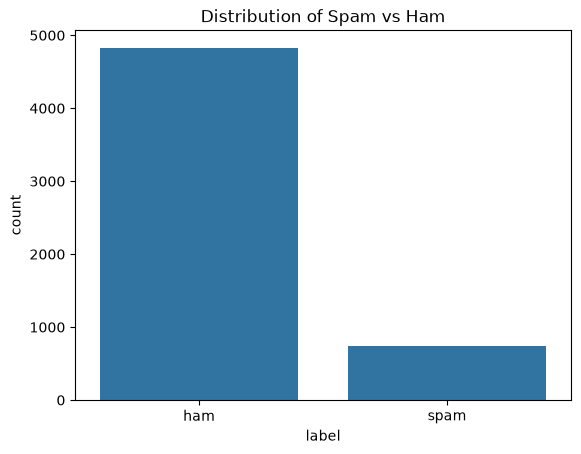

In [3]:
print(df.info())
print('\nTarget Distribution:')
print(df['label'].value_counts())

sns.countplot(x='label', data=df)
plt.title('Distribution of Spam vs Ham')
plt.show()

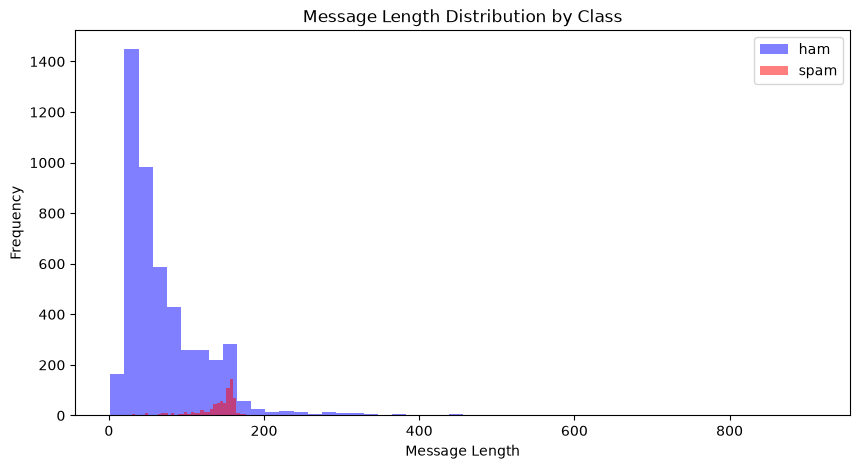

In [4]:
# Let's look at message length as a potential feature
df['length'] = df['message'].apply(len)

plt.figure(figsize=(10, 5))
df[df['label'] == 'ham']['length'].plot(bins=50, kind='hist', alpha=0.5, label='ham', color='blue')
df[df['label'] == 'spam']['length'].plot(bins=50, kind='hist', alpha=0.5, label='spam', color='red')
plt.legend()
plt.title('Message Length Distribution by Class')
plt.xlabel('Message Length')
plt.show()

> **📌 Decision Note — Why Basic text cleaning?**
>
> **Chosen approach:** Lowercasing, punctuation removal, and stripping whitespaces
>
> **Why this works:** Standardizes the vocabulary, preventing 'Hello' and 'hello!' from being treated as different words.
>
> **Alternatives we could have used:**
> | Option | Pros | Cons |
> |--------|------|------|
> | Keep punctuation | Might capture spammy patterns (e.g., 'WIN!!!') | Increases vocabulary size massively; BoW models handle huge vocabularies poorly. |
> | Advanced Lemmatization | Reduces words to base dictionary form | Overkill for simple spam classification, and computationally expensive. |
>
> **Why we chose this over alternatives:** Simple text cleaning provides a fast, robust baseline for this easy dataset.

## 3. Text Cleaning

In [5]:
df['cleaned_message'] = df['message'].apply(clean_text_basic)
df[['label', 'message', 'cleaned_message']].head()

,label,message,cleaned_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## 4. Save Processed Data

In [6]:
df.to_csv('../data/processed/cleaned_sms.csv', index=False)
print('Saved cleaned dataset.')

Saved cleaned dataset.


## Key Takeaways
- [x] Data is highly imbalanced (mostly ham).
- [x] Spam messages tend to be significantly longer than ham messages.
- [x] Cleaned data is saved and ready for vectorization.